HDA-8: SOCIAL MEDIA LANGUAGE ANALYSIS FOR ANXIETY SUBTYPE CLASSIFICATION

In [4]:
pip install praw pandas tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 kB 4.8 MB/s eta 0:00:00


In [5]:
import praw
import pandas as pd
from tqdm import tqdm

# Initialize Reddit API client
reddit = praw.Reddit(
    client_id="bzxlMUrn4ix-gPIBAnMoKw",
    client_secret="I1bsZmqbwanYLHzlPdcyMOVam4K8vQ",
    user_agent="HDA8_AnxietyProject:v1.0 (by u/Melodic-Let-2686)"
)

# Define subreddits and number of posts
subreddits = ['anxiety', 'panicdisorder', 'socialanxiety']
n_posts = 500  # per subreddit

posts_data = []

for sub in subreddits:
    for post in tqdm(reddit.subreddit(sub).hot(limit=n_posts), desc=f"Collecting {sub}"):
        if post.selftext:
            posts_data.append({
                "post_id": post.id,
                "subreddit": sub,
                "title": post.title,
                "text": post.selftext,
                "created_utc": post.created_utc,
                "score": post.score
            })

# Convert to DataFrame
df = pd.DataFrame(posts_data)
print(df.head())

# Save to CSV
df.to_csv("reddit_anxiety_raw.csv", index=False)


It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/latest/getting_started/multiple_instances.html#discord-bots-and-asynchronous-environments for more info.

It is strongly recommended to use Async PRAW: https://asyncpraw.readthedocs.io.
See https://praw.readthedocs.io/en/l

   post_id subreddit                                              title  \
0  1p3qivb   anxiety                            Monthly Check-In Thread   
1  1pofxsf   anxiety                    I’m scared I have schizophrenia   
2  1pojqqf   anxiety                                 When does it stop?   
3  1potybz   anxiety  How I finally quit vaping and kept my anxiety ...   
4  1por7h8   anxiety                       My anxiety is unbearable now   

                                                text   created_utc  score  
0  Hello everyone! Welcome to the r/Anxiety month...  1.763809e+09      4  
1  I (21F) have anxiety and OCD. Today I was edit...  1.765925e+09    107  
2  I'm sick of it. Every single day, constantly, ...  1.765935e+09     42  
3  Just wanted to share something that’s helped m...  1.765970e+09      5  
4  I'll start this off by saying my anxiety nowad...  1.765959e+09      8  


In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/reddit_anxiety_raw.csv")

# Show first 5 rows
df.head()

,post_id,subreddit,title,text,created_utc,score
0,1p3qivb,anxiety,Monthly Check-In Thread,Hello everyone! Welcome to the r/Anxiety month...,1.763809e+09,4
1,1pofxsf,anxiety,I’m scared I have schizophrenia,I (21F) have anxiety and OCD. Today I was edit...,1.765925e+09,107
2,1pojqqf,anxiety,When does it stop?,"I'm sick of it. Every single day, constantly, ...",1.765935e+09,42
3,1potybz,anxiety,How I finally quit vaping and kept my anxiety ...,Just wanted to share something that’s helped m...,1.765970e+09,5
4,1por7h8,anxiety,My anxiety is unbearable now,I'll start this off by saying my anxiety nowad...,1.765959e+09,8


In [7]:
df['text'] = df['text'].str.replace(r'http\S+', '', regex=True)  # remove URLs
df['text'] = df['text'].str.replace(r'\n', ' ', regex=True)     # remove newlines
df.dropna(subset=['text'], inplace=True)
df.to_csv("reddit_anxiety_clean.csv", index=False)


In [8]:
def label_subtype(text):
    text = text.lower()
    if any(k in text for k in ['panic attack', 'heart racing', 'can’t breathe', 'hyperventilate']):
        return 'panic'
    elif any(k in text for k in ['public speaking', 'embarrassment', 'fear of people', 'judged']):
        return 'social_anxiety'
    elif any(k in text for k in ['constant worry', 'overthink', 'can’t relax']):
        return 'gad'
    else:
        return 'unspecified'

df['label'] = df['text'].apply(label_subtype)
df.to_csv("reddit_anxiety_labeled.csv", index=False)


In [9]:
import pandas as pd
# Load the dataset
df = pd.read_csv("/content/reddit_anxiety_labeled.csv")

# Show first 5 rows
df.head(20)


,post_id,subreddit,title,text,created_utc,score,label
0,1p3qivb,anxiety,Monthly Check-In Thread,Hello everyone! Welcome to the r/Anxiety month...,1.763809e+09,4,unspecified
1,1pofxsf,anxiety,I’m scared I have schizophrenia,I (21F) have anxiety and OCD. Today I was edit...,1.765925e+09,107,unspecified
2,1pojqqf,anxiety,When does it stop?,"I'm sick of it. Every single day, constantly, ...",1.765935e+09,42,unspecified
3,1potybz,anxiety,How I finally quit vaping and kept my anxiety ...,Just wanted to share something that’s helped m...,1.765970e+09,5,unspecified
4,1por7h8,anxiety,My anxiety is unbearable now,I'll start this off by saying my anxiety nowad...,1.765959e+09,8,panic
5,1potfwn,anxiety,How to get treatment without insurance?,I make too much for Medicaid and I can’t affor...,1.765968e+09,3,unspecified
6,1pos0rt,anxiety,Anxiety without clear thoughts — just constant...,Some days my anxiety doesn’t come with obvious...,1.765963e+09,4,unspecified
7,1pood0s,anxiety,Severe panic attack out of nowhere??,Does anybody go months without a severe panic ...,1.765949e+09,9,panic
8,1popppx,anxiety,Ongoing physical symptoms + anxiety spiral — s...,"Hi everyone, I’m posting here because I’ve be...",1.765954e+09,7,unspecified
9,1posiqj,anxiety,Had to stop watching horror,"It’s not bc I’m scared, but bc of the intentio...",1.765965e+09,3,unspecified


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import re

# Load dataset
df = pd.read_csv("reddit_anxiety_labeled.csv")

# Display first few rows
df.head()


,post_id,subreddit,title,text,created_utc,score,label
0,1p3qivb,anxiety,Monthly Check-In Thread,Hello everyone! Welcome to the r/Anxiety month...,1.763809e+09,4,unspecified
1,1pofxsf,anxiety,I’m scared I have schizophrenia,I (21F) have anxiety and OCD. Today I was edit...,1.765925e+09,107,unspecified
2,1pojqqf,anxiety,When does it stop?,"I'm sick of it. Every single day, constantly, ...",1.765935e+09,42,unspecified
3,1potybz,anxiety,How I finally quit vaping and kept my anxiety ...,Just wanted to share something that’s helped m...,1.765970e+09,5,unspecified
4,1por7h8,anxiety,My anxiety is unbearable now,I'll start this off by saying my anxiety nowad...,1.765959e+09,8,panic


In [11]:
df.info()
df.describe(include='all')
print("Shape:", df.shape)
print("Missing values:\n", df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1487 entries, 0 to 1486
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      1487 non-null   object 
 1   subreddit    1487 non-null   object 
 2   title        1487 non-null   object 
 3   text         1487 non-null   object 
 4   created_utc  1487 non-null   float64
 5   score        1487 non-null   int64  
 6   label        1487 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 81.4+ KB
Shape: (1487, 7)
Missing values:
 post_id        0
subreddit      0
title          0
text           0
created_utc    0
score          0
label          0
dtype: int64


/tmp/ipython-input-2945031441.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


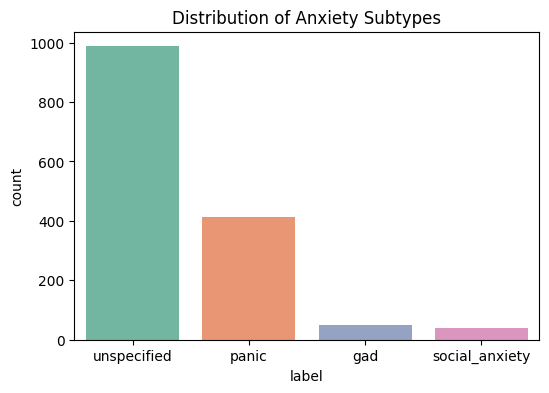

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title("Distribution of Anxiety Subtypes")
plt.show()


EDA FULL SCRIPT

In [ ]:
pip install pandas numpy matplotlib seaborn wordcloud nltk scikit-learn textblob vaderSentiment


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Loaded dataset: (1491, 6)


,post_id,subreddit,title,text,created_utc,score
0,1p3qivb,anxiety,Monthly Check-In Thread,Hello everyone! Welcome to the r/Anxiety month...,1.763809e+09,5
1,1pngeis,anxiety,I wish I never got diagnosed with GAD,"Not even just cus of the anxiety. No, I take Z...",1.765827e+09,158
2,1pnbkdh,anxiety,Why does resting feel like failure,I took a day off because I’m burned out. I kne...,1.765816e+09,204
3,1pntiho,anxiety,Job interview - Wish me well lads,"Hey guys, got a job interview to get me out of...",1.765861e+09,17
4,1pny9wd,anxiety,"Does anyone else get stuck in the ""am I sick b...",We all know pretty much that anxiety and panic...,1.765879e+09,6



--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1491 entries, 0 to 1490
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   post_id      1491 non-null   object 
 1   subreddit    1491 non-null   object 
 2   title        1491 non-null   object 
 3   text         1491 non-null   object 
 4   created_utc  1491 non-null   float64
 5   score        1491 non-null   int64  
dtypes: float64(1), int64(1), object(4)
memory usage: 70.0+ KB


None

...

,term,score
1256,panic,43.636195
1004,like,32.572811
98,anxiety,30.141408
919,just,30.027470
607,feel,27.328870
1857,ve,25.804105
156,attacks,22.382819
149,attack,21.973676
1259,panic attacks,21.036657
1258,panic attack,18.346512



Top tokens for label = gad (sample):


,term,score
49,anxiety,3.543177
1464,like,3.274592
1915,ve,2.870263
1418,just,2.853468
1242,feel,2.691423
797,don,2.550870
1434,know,2.261949
1862,time,1.923154
1739,sleep,1.741169
1258,feel like,1.699755



Saved top unigram/bigram keyword CSVs.

Sentiment stats by label:


,neg,neu,pos,compound
label,,,,
gad,0.1320,0.767,0.0870,-0.79920
panic,0.1700,0.729,0.0950,-0.91750
social_anxiety,0.1165,0.763,0.1115,0.14795
unspecified,0.1150,0.775,0.0910,-0.21540


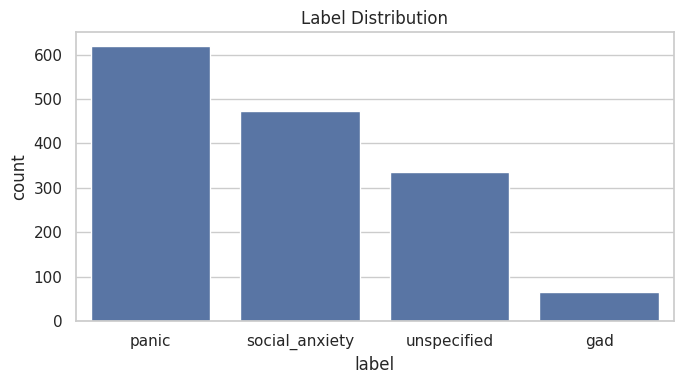

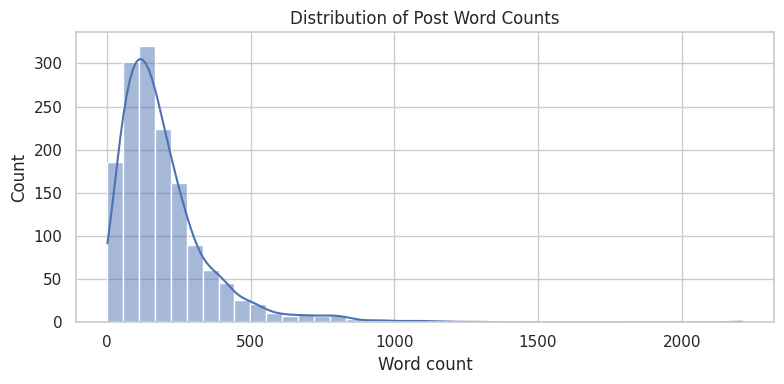

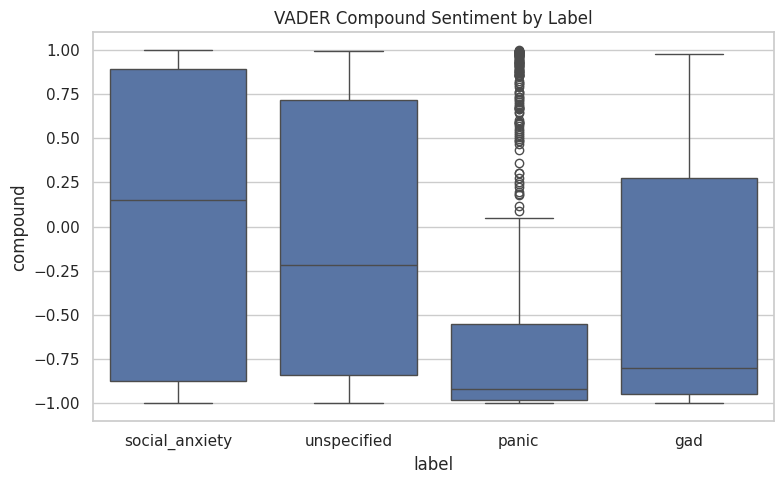

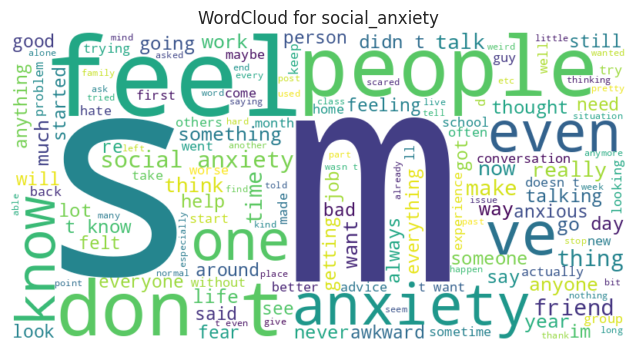

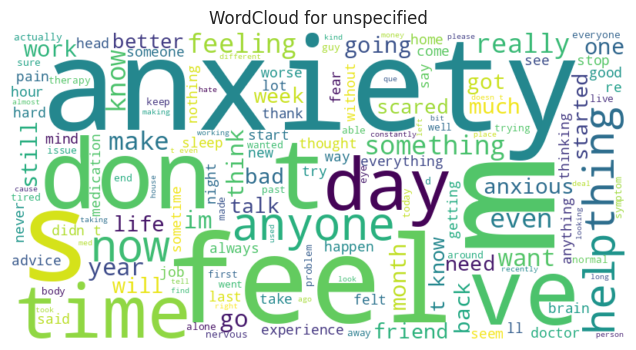

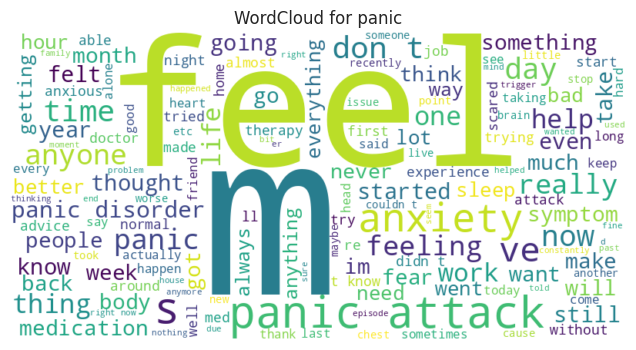

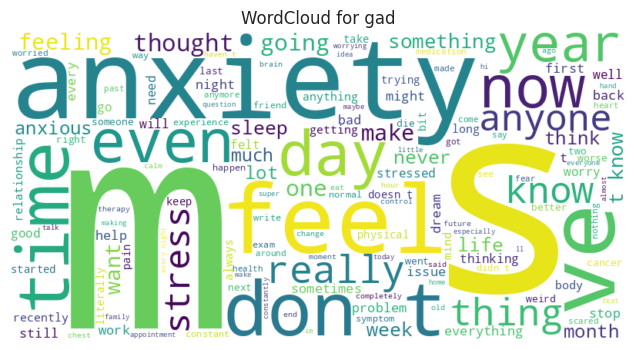

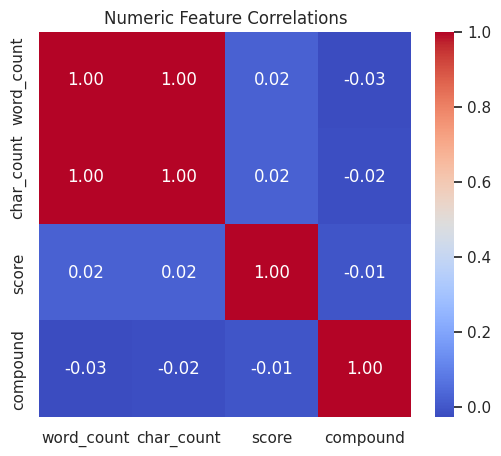

,word_count,char_count,score,compound
word_count,1.00000,0.996560,0.023700,-0.026570
char_count,0.99656,1.000000,0.024733,-0.020727
score,0.02370,0.024733,1.000000,-0.005404
compound,-0.02657,-0.020727,-0.005404,1.000000



Saved cleaned dataset: reddit_anxiety_cleaned_for_eda.csv
Saved: top_tokens_social_anxiety.csv
Saved: top_tokens_unspecified.csv
Saved: top_tokens_panic.csv
Saved: top_tokens_gad.csv
Saved EDA summary: eda_summary.json

Top 10 posts labeled 'panic' (title + snippet):


,post_id,title,clean_text
4,1pny9wd,"Does anyone else get stuck in the ""am I sick b...",does anyone else get stuck in the am i sick be...
14,1pnstp5,Anyone else get mostly physical symptoms?,anyone else get mostly physical symptoms i get...
20,1pnw140,Does Loud music help anyone?,does loud music help anyone i have always love...
26,1pngj8b,Anxiety is destroying my life,anxiety is destroying my life hi everyone pls ...
32,1pnkjg8,What are your anxiety feelings and symptoms?,what are your anxiety feelings and symptoms wh...
35,1pnwq9p,High anxiety and heart rate help,high anxiety and heart rate help sorry for bad...
36,1pnh2kq,Death thought,death thought hello all i ve dealt with severe...
37,1pnwnbn,insomnia with health anxiety,insomnia with health anxiety so i ve been a re...
39,1pnwd3v,FEAR of having a stomach issue in public,fear of having a stomach issue in public hello...
43,1pnvpfu,Screaming and Panicking Freaking Out Neighbors,screaming and panicking freaking out neighbors...



Random examples from each label for manual spot-checking:


,post_id,clean_text,label
1024,1pn26ao,why do i randomly get social anxiety while oth...,social_anxiety
1405,1pe9a79,how to make friends at uni i feel worse than e...,social_anxiety


,post_id,clean_text,label
11,1pny7l7,is it time for a new therapist i have been in ...,unspecified
419,1ploci9,stomach pain anyone else often getting stomach...,unspecified


,post_id,clean_text,label
838,1nd23ww,please read this please i have always been a v...,panic
725,1o5g5s4,looking for reassurance i was diagnosed with p...,panic


,post_id,clean_text,label
110,1pnib1c,is my relationship worth it i ve just gotten i...,gad
469,1pl1t17,anxiety hey everyone i m having a hard time wi...,gad



EDA complete. Check the saved CSVs, images (displayed inline), and eda_summary.json for results.


In [ ]:
# EDA for reddit_anxiety_raw.csv

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Text tools
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, ngrams
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud

# --- NLTK downloads (first run) ---
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')  # if using vader from nltk (vaderSentiment covers it)

# -------------------------
# 1. Load dataset
# -------------------------
DATA_PATH = "reddit_anxiety_raw.csv"   # change path if needed
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"File not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print("Loaded dataset:", df.shape)
display(df.head())

# -------------------------
# 2. Quick structure checks
# -------------------------
print("\n--- Info ---")
display(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

print("\nDuplicates (post_id):", df['post_id'].duplicated().sum() if 'post_id' in df.columns else "no post_id column")

# -------------------------
# 3. Combine title + text
# -------------------------
title_col = 'title' if 'title' in df.columns else None
text_col = 'text' if 'text' in df.columns else None

if title_col and text_col:
    df['combined_text'] = df[title_col].fillna('') + " " + df[text_col].fillna('')
elif text_col:
    df['combined_text'] = df[text_col].fillna('')
else:
    raise ValueError("Dataset must contain a text column (named 'text' or 'title').")

# -------------------------
# 4. Cleaning & anonymization
#   - remove urls, usernames, subs, special chars
#   - lowercasing
# -------------------------
STOPWORDS = set(stopwords.words('english'))

def anonymize_and_clean(text):
    if pd.isnull(text):
        return ""
    t = str(text)
    # remove URLs
    t = re.sub(r'http\S+|www\.\S+', '', t)
    # remove reddit user references (u/username) and subreddit refs (r/subreddit)
    t = re.sub(r'u\/\w+', '[USER]', t)
    t = re.sub(r'r\/\w+', '[SUB]', t)
    # remove email-like tokens
    t = re.sub(r'\S+@\S+', '', t)
    # remove non-alphanumeric characters (keep spaces)
    t = re.sub(r'[^A-Za-z0-9\s]', ' ', t)
    # collapse whitespace and lowercase
    t = re.sub(r'\s+', ' ', t).strip().lower()
    return t

df['clean_text'] = df['combined_text'].apply(anonymize_and_clean)

# drop rows with empty text (after cleaning)
before = df.shape[0]
df = df[df['clean_text'].str.strip() != ""].reset_index(drop=True)
after = df.shape[0]
print(f"\nDropped {before-after} empty posts after cleaning. Remaining: {after}")

# -------------------------
# 5. Basic descriptive stats
# -------------------------
print("\n--- Basic Stats ---")
print("Number of posts:", df.shape[0])
if 'subreddit' in df.columns:
    print("Posts per subreddit:")
    display(df['subreddit'].value_counts())

# text length metrics
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean_text'].apply(len)
print("\nWord count statistics:")
display(df['word_count'].describe())

# upvote / score distribution (if available)
if 'score' in df.columns:
    print("\nScore summary:")
    display(df['score'].describe())

# -------------------------
# 6. Label distribution (if label exists)
# -------------------------
if 'label' in df.columns:
    print("\nLabel distribution (existing):")
    display(df['label'].value_counts())
else:
    print("\nNo label column found. You can use weak labeling based on keywords later.")

# -------------------------
# 7. Weak labeling
#    Use this to seed labels if label is missing.
# -------------------------
# -------------------------
#weak labelling
def weak_label(text):
    # define expanded keyword lists (you can extend these)
    panic_keywords = ['panic', 'panic attack', 'panic attacks', 'heart racing', 'racing heart',
                      'can t breathe', 'cannot breathe', 'hyperventilate', 'suffocat', 'chest tight', 'dizzy', 'lightheaded']
    social_keywords = ['public speaking', 'social anxiety', 'social phobia', 'people', 'crowd', 'stare', 'judged', 'embarrass', 'presentation', 'audience', 'awkward','mental health','pressure']
    gad_keywords = ['worry', 'overthink', 'overthinking', 'can t relax', 'cant relax', 'always worried', 'restless', 'nervous all the time', 'ruminate', 'stress']
    t = text.lower()
    # check panic first (order matters if keywords overlap)
    if any(k in t for k in panic_keywords):
        return 'panic'
    if any(k in t for k in social_keywords):
        return 'social_anxiety'
    if any(k in t for k in gad_keywords):
        return 'gad'
    return 'unspecified'

# only create weak labels if no 'label' column exists, otherwise preserve original
if 'label' not in df.columns:
    df['label'] = df['clean_text'].apply(weak_label)
    print("\nWeak labeling applied. Label counts:")
    display(df['label'].value_counts())
else:
    print("\nPreserving existing labels.")




# -------------------------
# 8. Top n-grams and token frequency (global + per label)
# -------------------------
def get_top_ngrams(corpus, n=None, ngram_range=(1,1)):
    vec = TfidfVectorizer(max_features=2000, ngram_range=ngram_range, stop_words='english')
    X = vec.fit_transform(corpus)
    sums = np.array(X.sum(axis=0)).flatten()
    terms = vec.get_feature_names_out()
    df_terms = pd.DataFrame({'term': terms, 'score': sums})
    return df_terms.sort_values(by='score', ascending=False).head(n)

# top unigrams overall
top_unigrams = get_top_ngrams(df['clean_text'], n=50, ngram_range=(1,1))
print("\nTop unigrams (corpus):")
display(top_unigrams.head(20))

# top bigrams
top_bigrams = get_top_ngrams(df['clean_text'], n=50, ngram_range=(2,2))
print("\nTop bigrams (corpus):")
display(top_bigrams.head(20))

# top tokens per label
labels = df['label'].unique()
top_by_label = {}
for lab in labels:
    subset = df[df['label'] == lab]
    if subset.shape[0] > 0:
        top_by_label[lab] = get_top_ngrams(subset['clean_text'], n=40, ngram_range=(1,2))
        print(f"\nTop tokens for label = {lab} (sample):")
        display(top_by_label[lab].head(15))

# Save keyword lists
keywords_df = top_unigrams.copy()
keywords_df.to_csv("reddit_anxiety_keywords_unigrams.csv", index=False)
top_bigrams.to_csv("reddit_anxiety_keywords_bigrams.csv", index=False)
print("\nSaved top unigram/bigram keyword CSVs.")

# -------------------------
# 9. Sentiment analysis with VADER
# -------------------------
analyzer = SentimentIntensityAnalyzer()

def vader_scores(text):
    s = analyzer.polarity_scores(text)
    return s['neg'], s['neu'], s['pos'], s['compound']

df[['neg', 'neu', 'pos', 'compound']] = df['clean_text'].apply(lambda x: pd.Series(vader_scores(x)))

print("\nSentiment stats by label:")
display(df.groupby('label')[['neg','neu','pos','compound']].median())

# -------------------------
# 10. Visualizations
#    (bar plots, histograms, wordclouds)
# -------------------------
sns.set(style="whitegrid")

# label distribution plot
plt.figure(figsize=(7,4))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.title("Label Distribution")
plt.tight_layout()
plt.show()

# post length histogram
plt.figure(figsize=(8,4))
sns.histplot(df['word_count'], bins=40, kde=True)
plt.title("Distribution of Post Word Counts")
plt.xlabel("Word count")
plt.tight_layout()
plt.show()

# sentiment distribution by label (boxplot)
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='label', y='compound')
plt.title("VADER Compound Sentiment by Label")
plt.tight_layout()
plt.show()

# wordclouds per label
for lab in labels:
    text = " ".join(df[df['label'] == lab]['clean_text'].tolist())
    if len(text.strip()) == 0:
        continue
    wc = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(text)
    plt.figure(figsize=(10,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud for {lab}")
    plt.show()

# -------------------------
# 11. Correlations (numeric features)
# -------------------------
numeric_cols = ['word_count', 'char_count', 'score'] if 'score' in df.columns else ['word_count', 'char_count']
numeric_cols = [c for c in numeric_cols if c in df.columns]

if len(numeric_cols) >= 2:
    corr = df[numeric_cols + ['compound']].corr()
    plt.figure(figsize=(6,5))
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Numeric Feature Correlations")
    plt.show()
    display(corr)

# -------------------------
# 12. Save cleaned dataset and summaries
# -------------------------
df.to_csv("reddit_anxiety_cleaned_for_eda.csv", index=False)
print("\nSaved cleaned dataset: reddit_anxiety_cleaned_for_eda.csv")

# Save per-label top token CSVs
for lab, tokens_df in top_by_label.items():
    fname = f"top_tokens_{lab}.csv"
    tokens_df.to_csv(fname, index=False)
    print("Saved:", fname)

# summary stats file
summary = {
    "n_posts": int(df.shape[0]),
    "labels_counts": df['label'].value_counts().to_dict(),
    "avg_word_count": float(df['word_count'].mean()),
    "median_compound_sentiment": float(df['compound'].median())
}
with open("eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("Saved EDA summary: eda_summary.json")

# -------------------------
# 13. Quick manual-inspection helpers
# -------------------------
print("\nTop 10 posts labeled 'panic' (title + snippet):")
if 'title' in df.columns:
    display(df[df['label']=='panic'][['post_id','title','clean_text']].head(10))
else:
    display(df[df['label']=='panic'][['post_id','clean_text']].head(10))

print("\nRandom examples from each label for manual spot-checking:")
for lab in labels:
    sample = df[df['label']==lab].sample(n=2) if df[df['label']==lab].shape[0] >= 2 else df[df['label']==lab]
    display(sample[['post_id', 'clean_text', 'label']])

print("\nEDA complete. Check the saved CSVs, images (displayed inline), and eda_summary.json for results.")


Train-Test Split

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------
# 1. Load the dataset produced by your EDA code
# ---------------------------------------------
df = pd.read_csv("reddit_anxiety_cleaned_for_eda.csv")

# ---------------------------------------------
# 2. Select the correct columns
# ---------------------------------------------
TEXT_COL = "clean_text"

# If you ran refined labeling:
LABEL_COL = "refined_label"

# If refined_label does NOT exist, use this:
if LABEL_COL not in df.columns:
    LABEL_COL = "label"

print("Using text column:", TEXT_COL)
print("Using label column:", LABEL_COL)

# ---------------------------------------------
# 3. Remove rows with missing labels or text
# ---------------------------------------------
df = df.dropna(subset=[TEXT_COL, LABEL_COL]).copy()

# Exclude "unspecified" — they harm classifier accuracy
df = df[df[LABEL_COL] != "unspecified"]

# ---------------------------------------------
# 4. Train–Test Split (Stratified)
# ---------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    df[TEXT_COL],
    df[LABEL_COL],
    test_size=0.20,
    random_state=42,
    stratify=df[LABEL_COL]
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))



Using text column: clean_text
Using label column: label
Train size: 924
Test size: 232


Feature Extraction


Accuracy: 0.8448275862068966

Classification Report:

                precision    recall  f1-score   support

           gad       0.57      0.31      0.40        13
         panic       0.88      0.88      0.88       124
social_anxiety       0.82      0.87      0.85        95

      accuracy                           0.84       232
     macro avg       0.76      0.69      0.71       232
  weighted avg       0.84      0.84      0.84       232



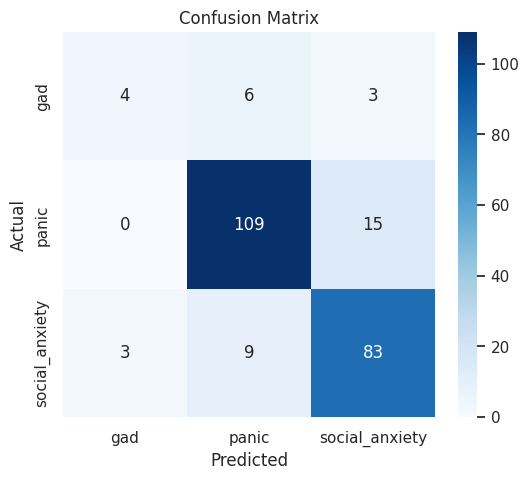

In [ ]:
# ---------------------------------------------
# 5. TF-IDF Vectorization
# ---------------------------------------------
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# ---------------------------------------------
# 6. Train the model
# ---------------------------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train_tfidf, y_train)

# ---------------------------------------------
# 7. Evaluate
# ---------------------------------------------
y_pred = model.predict(X_test_tfidf)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------------------------------------
# 8. Confusion Matrix
# ---------------------------------------------
labels = sorted(df[LABEL_COL].unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


using BERT embeddings

In [ ]:
!pip install -q sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
import pandas as pd
import numpy as np

# Load your EDA dataset
df = pd.read_csv("reddit_anxiety_cleaned_for_eda.csv")

# Remove unspecified labels
df = df[df["label"] != "unspecified"].copy()

# Load SBERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

# Create embeddings (768-dim vector per post)
embeddings = model.encode(df["clean_text"].tolist(), batch_size=32, show_progress_bar=True)

# Convert to NumPy
embeddings = np.array(embeddings)

print("Embeddings shape:", embeddings.shape)


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

Embeddings shape: (1156, 384)


models

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_tfidf, y_train)
y_pred_lr = log_reg.predict(X_test_tfidf)

print("\n📌 Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


📌 Logistic Regression Results:
Accuracy: 0.8448275862068966
                precision    recall  f1-score   support

           gad       0.57      0.31      0.40        13
         panic       0.88      0.88      0.88       124
social_anxiety       0.82      0.87      0.85        95

      accuracy                           0.84       232
     macro avg       0.76      0.69      0.71       232
  weighted avg       0.84      0.84      0.84       232



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=50,
    class_weight='balanced'
)

rf.fit(X_train_tfidf, y_train)
y_pred_rf = rf.predict(X_test_tfidf)

print("\n📌 Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



📌 Random Forest Results:
Accuracy: 0.8836206896551724
                precision    recall  f1-score   support

           gad       1.00      0.08      0.14        13
         panic       0.93      0.92      0.92       124
social_anxiety       0.83      0.95      0.89        95

      accuracy                           0.88       232
     macro avg       0.92      0.65      0.65       232
  weighted avg       0.89      0.88      0.86       232



In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred_nb = nb.predict(X_test_tfidf)

print("\n📌 Naive Bayes Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))



📌 Naive Bayes Results:
Accuracy: 0.7931034482758621
                precision    recall  f1-score   support

           gad       0.00      0.00      0.00        13
         panic       0.74      0.95      0.83       124
social_anxiety       0.90      0.69      0.79        95

      accuracy                           0.79       232
     macro avg       0.55      0.55      0.54       232
  weighted avg       0.77      0.79      0.77       232



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipython-input-1303533310.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="viridis")


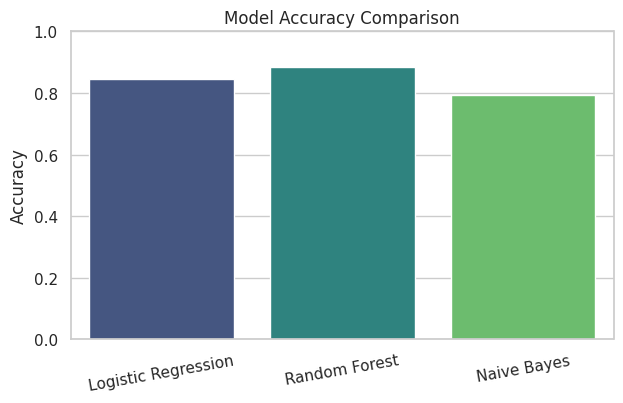

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score

# Calculate accuracies
acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_nb = accuracy_score(y_test, y_pred_nb)

# Prepare data
models = ["Logistic Regression", "Random Forest", "Naive Bayes"]
accuracies = [acc_lr, acc_rf, acc_nb]

# Plot
plt.figure(figsize=(7,4))
sns.barplot(x=models, y=accuracies, palette="viridis")
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.xticks(rotation=10)
plt.show()


🎯 RANDOM FOREST ACCURACY: 0.8836206896551724

📌 RANDOM FOREST – CLASSIFICATION REPORT:

                precision    recall  f1-score   support

           gad       1.00      0.08      0.14        13
         panic       0.93      0.92      0.92       124
social_anxiety       0.83      0.95      0.89        95

      accuracy                           0.88       232
     macro avg       0.92      0.65      0.65       232
  weighted avg       0.89      0.88      0.86       232



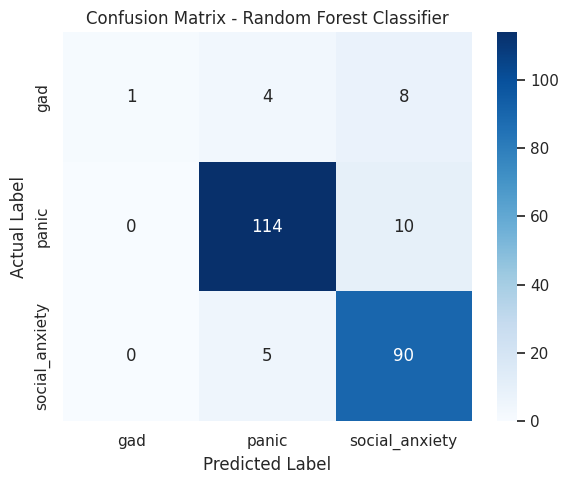

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------
# 1. ACCURACY SCORE
# ---------------------------------------
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print("🎯 RANDOM FOREST ACCURACY:", rf_accuracy)

# ---------------------------------------
# 2. CLASSIFICATION REPORT
# ---------------------------------------
print("\n📌 RANDOM FOREST – CLASSIFICATION REPORT:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# ---------------------------------------
# 3. CONFUSION MATRIX (ONLY RANDOM FOREST)
# ---------------------------------------
cm = confusion_matrix(y_test, y_pred_rf)
labels = sorted(df["label"].unique())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix - Random Forest Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import accuracy_score

# Training accuracy
train_pred = log_reg.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, train_pred)
print("🔥 Training Accuracy:", train_acc)

# Testing accuracy
test_pred = log_reg.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, test_pred)
print("🎯 Testing Accuracy:", test_acc)


🔥 Training Accuracy: 0.9761904761904762
🎯 Testing Accuracy: 0.8448275862068966


🔄 Generating BERT embeddings...


Batches:   0%|          | 0/37 [00:00<?, ?it/s]

BERT embedding shape: (1156, 384)
🔥 FINAL BERT + LOGISTIC REGRESSION ACCURACY: 0.8017241379310345

📌 CLASSIFICATION REPORT:
                precision    recall  f1-score   support

           gad       0.26      0.85      0.40        13
         panic       0.93      0.86      0.90       124
social_anxiety       0.91      0.72      0.80        95

      accuracy                           0.80       232
     macro avg       0.70      0.81      0.70       232
  weighted avg       0.88      0.80      0.83       232



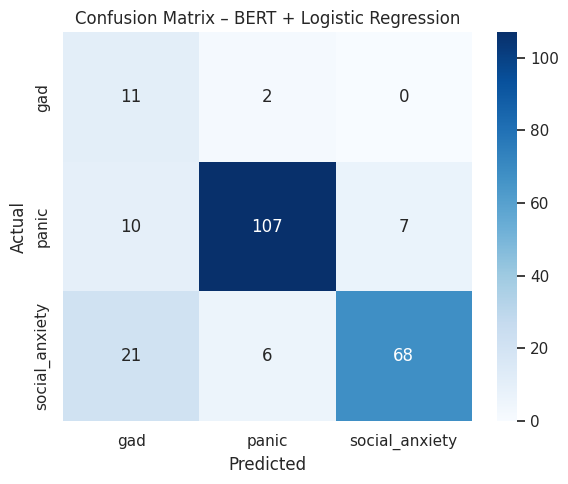

In [ ]:
# ============================================================
#     FULL SENTENCE-BERT PIPELINE AFTER EDA
# ============================================================

!pip install sentence-transformers

import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------------
# 1. LOAD CLEANED DATA FROM EDA
# -------------------------------------------------
df = pd.read_csv("reddit_anxiety_cleaned_for_eda.csv")

# Remove very short or useless posts (improves accuracy)
df = df[df["clean_text"].str.split().apply(len) > 5].reset_index(drop=True)

# Remove "unspecified" because BERT cannot learn it well
df = df[df["label"] != "unspecified"].reset_index(drop=True)

texts = df["clean_text"].tolist()
labels = df["label"].tolist()

# -------------------------------------------------
# 2. LABEL ENCODING
# -------------------------------------------------
le = LabelEncoder()
y = le.fit_transform(labels)

# -------------------------------------------------
# 3. LOAD SENTENCE-BERT MODEL
# -------------------------------------------------
model = SentenceTransformer("all-MiniLM-L6-v2")

print("🔄 Generating BERT embeddings...")
X = model.encode(texts, show_progress_bar=True)

print("BERT embedding shape:", X.shape)   # (num_samples, 384)

# -------------------------------------------------
# 4. TRAIN–TEST SPLIT
# -------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------------------------------
# 5. BEST MODEL FOR BERT: LOGISTIC REGRESSION
# -------------------------------------------------
lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"   # balances panic/social/gad
)

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# -------------------------------------------------
# 6. ACCURACY RESULTS
# -------------------------------------------------
acc = accuracy_score(y_test, y_pred)
print("🔥 FINAL BERT + LOGISTIC REGRESSION ACCURACY:", acc)

print("\n📌 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# -------------------------------------------------
# 7. CONFUSION MATRIX
# -------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)

plt.title("Confusion Matrix – BERT + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
df['label'].value_counts()
df.shape


(1156, 15)

In [ ]:
!pip install -U streamlit pyngrok

In [ ]:
# Start streamlit in the background and write logs to streamlit.log
# Adjust the path if your app.py is elsewhere (e.g., /content/drive/MyDrive/app.py)
import os
os.environ['LC_ALL'] = 'en_US.UTF-8'
os.environ['LANG'] = 'en_US.UTF-8'

!nohup streamlit run /content/app.py --server.port 8501 --server.enableCORS false > streamlit.log 2>&1 &

In [ ]:
from pyngrok import ngrok

# 🔑 Replace with your actual token from the ngrok dashboard
ngrok.set_auth_token("350XS5sS5MS8r2rU4GRV27l147V_7Mb76t42EdaBQwGZUyH5j")

print("✅ Auth token set successfully!")

✅ Auth token set successfully!


ngrok Auth token:350XS5sS5MS8r2rU4GRV27l147V_7Mb76t42EdaBQwGZUyH5j

In [ ]:
!nohup streamlit run /content/app.py --server.port 8501 --server.enableCORS false > streamlit.log 2>&1 &

In [ ]:
public_url = ngrok.connect(8501, "http")
print("🌐 Open this Streamlit App URL:", public_url)

🌐 Open this Streamlit App URL: NgrokTunnel: "https://unstriking-gratifyingly-magan.ngrok-free.dev" -> "http://localhost:8501"
